# Actividad 3
A partir del dataset usado en la Actividad 2, transformar y visualizar los datos en Databricks CE, generando columnas derivadas de fecha, un resumen mensual, un proceso de limpieza con evidencia antes/después y visualizaciones categóricas. Finalmente, elaborar un video explicativo (≤ 3 minutos, ≤ 50 MB).

##1️⃣Transformaciones de fecha

In [0]:
%sql
SELECT
  fecha,
  year(fecha)  AS anio,
  month(fecha) AS mes,
  day(fecha)   AS dia,
  dayofweek(fecha)  AS dia_semana,
  date_format(fecha,'EEEE')  AS nombre_dia
FROM catalog_movilidad.schema_transito.tabla_incidente;

fecha,anio,mes,dia,dia_semana,nombre_dia
2017-05-05 00:00:00,2017,5,5,6,Friday
2017-06-06 00:00:00,2017,6,6,3,Tuesday
2017-05-10 00:00:00,2017,5,10,4,Wednesday
2017-05-12 00:00:00,2017,5,12,6,Friday
2017-04-14 00:00:00,2017,4,14,6,Friday
2017-07-25 00:00:00,2017,7,25,3,Tuesday
2017-06-25 00:00:00,2017,6,25,1,Sunday
2017-05-30 00:00:00,2017,5,30,3,Tuesday
2017-05-02 00:00:00,2017,5,2,3,Tuesday
2017-07-24 00:00:00,2017,7,24,2,Monday


## 2️⃣Resumen mensual(nueva tabla)

In [0]:
%sql
CREATE OR REPLACE TABLE resumen_mensual AS
SELECT
  year(fecha)  AS anio,
  month(fecha) AS mes,
  COUNT(*)     AS n_registros,
  AVG(try_cast(cbml AS DOUBLE)) AS cbml_promedio
FROM catalog_movilidad.schema_transito.tabla_incidente
GROUP BY year(fecha), month(fecha);

num_affected_rows,num_inserted_rows


In [0]:
%sql
SELECT * FROM resumen_mensual LIMIT 10;

anio,mes,n_registros,cbml_promedio
2017,12,3782,2.221511665801483E7
2017,7,3892,2.4952373172126595E7
2017,11,3697,4.554676254572013E7
2017,4,3650,2.023796275754858E7
2017,5,4050,3.7529505114239745E7
2017,6,3730,1.2366948935867673E7
2017,9,4044,1.7199784466772992E7
2017,10,3889,1.6914257130011138E7
2017,3,3914,2.8991306155574277E7
2017,8,4220,2.612594393458184E7


## 3️⃣Limpieza evidencia antes/ despúes 

ANTES DE LA LIMPIEZA

In [0]:
%sql
SELECT clase, barrio, latitud, longitud, fecha
FROM catalog_movilidad.schema_transito.tabla_incidente
LIMIT 10;

clase,barrio,latitud,longitud,fecha
Choque,Rosales,6.23458147,-75.58965933,2017-05-05 00:00:00
Choque,Patio Bonito,6.20025821,-75.57313732,2017-06-06 00:00:00
Choque,San Javier No.1,6.25463126,-75.61943682,2017-05-10 00:00:00
Caida Ocupante,Barrio Colombia,6.22841134,-75.57187706,2017-05-12 00:00:00
Choque,Villa Flora,6.27719971,-75.58942029,2017-04-14 00:00:00
Choque,La Pilarica,6.27367747,-75.58203844,2017-07-25 00:00:00
Atropello,Villa Flora,6.28028167,-75.59180944,2017-06-25 00:00:00
Choque,La Candelaria,6.24872876,-75.56364208,2017-05-30 00:00:00
Choque,Campo Vald�s No. 2,6.27089288,-75.55335951,2017-05-02 00:00:00
Choque,Buenos Aires,6.24160284,-75.55873886,2017-07-24 00:00:00


DESPUÉS DE LA LIMPIEZA

In [0]:
%sql
CREATE OR REPLACE TABLE incidentes_limpios AS
WITH 
-- 1. LIMPIEZA INICIAL
stage_limpieza AS (
  SELECT
    OBJECTID,
    fecha,
    LOWER(TRIM(clase)) AS clase_limpia,
    LOWER(TRIM(barrio)) AS barrio_limpio,
    
    -- LATITUD: Manejo de strings vacíos, ceros y casteo seguro
    CASE 
      WHEN latitud = '' OR latitud IS NULL OR latitud = '0' THEN NULL
      ELSE TRY_CAST(latitud AS DOUBLE) 
    END AS latitud_raw,

    -- LONGITUD: Hacemos lo mismo para la longitud
    CASE 
      WHEN longitud = '' OR longitud IS NULL OR longitud = '0' THEN NULL
      ELSE TRY_CAST(longitud AS DOUBLE) 
    END AS longitud_raw

  FROM catalog_movilidad.schema_transito.tabla_incidente
),

-- 2. CÁLCULO DE ESTADÍSTICAS (Para ambas coordenadas)
stats AS (
  SELECT
    -- Medias para imputación
    AVG(latitud_raw) AS media_lat,
    AVG(longitud_raw) AS media_lon,
    
    -- Percentiles para Latitud
    percentile_approx(latitud_raw, 0.25) AS q1_lat,
    percentile_approx(latitud_raw, 0.75) AS q3_lat,

    -- Percentiles para Longitud
    percentile_approx(longitud_raw, 0.25) AS q1_lon,
    percentile_approx(longitud_raw, 0.75) AS q3_lon
  FROM stage_limpieza
  -- Filtramos nulos para no sesgar el cálculo de los cuartiles
  WHERE latitud_raw IS NOT NULL AND longitud_raw IS NOT NULL
),

-- 3. IMPUTACIÓN Y FILTRADO FINAL
final AS (
  SELECT
    d.OBJECTID,
    d.fecha,
    d.clase_limpia,
    d.barrio_limpio,
    
    -- Imputación: Si quedó NULL tras el casteo, ponemos la media
    COALESCE(d.latitud_raw, s.media_lat) AS latitud,
    COALESCE(d.longitud_raw, s.media_lon) AS longitud
    
  FROM stage_limpieza d
  CROSS JOIN stats s
  WHERE 
    -- FILTRO DE OUTLIERS (Aplicado a ambas coordenadas para mayor precisión)
    
    -- 1. Rango Latitud
    (COALESCE(d.latitud_raw, s.media_lat) BETWEEN 
      (s.q1_lat - 1.5 * (s.q3_lat - s.q1_lat)) AND 
      (s.q3_lat + 1.5 * (s.q3_lat - s.q1_lat)))
    
    AND 
    
    -- 2. Rango Longitud
    (COALESCE(d.longitud_raw, s.media_lon) BETWEEN 
      (s.q1_lon - 1.5 * (s.q3_lon - s.q1_lon)) AND 
      (s.q3_lon + 1.5 * (s.q3_lon - s.q1_lon)))
)

SELECT * FROM final;

num_affected_rows,num_inserted_rows


In [0]:
%sql
SELECT clase_limpia, barrio_limpio, latitud, longitud, fecha
FROM incidentes_limpios
LIMIT 10;

clase_limpia,barrio_limpio,latitud,longitud,fecha
choque,rosales,6.23458147,-75.58965933,2017-05-05 00:00:00
choque,patio bonito,6.20025821,-75.57313732,2017-06-06 00:00:00
choque,san javier no.1,6.25463126,-75.61943682,2017-05-10 00:00:00
caida ocupante,barrio colombia,6.22841134,-75.57187706,2017-05-12 00:00:00
choque,villa flora,6.27719971,-75.58942029,2017-04-14 00:00:00
choque,la pilarica,6.27367747,-75.58203844,2017-07-25 00:00:00
atropello,villa flora,6.28028167,-75.59180944,2017-06-25 00:00:00
choque,la candelaria,6.24872876,-75.56364208,2017-05-30 00:00:00
choque,campo vald�s no. 2,6.27089288,-75.55335951,2017-05-02 00:00:00
choque,buenos aires,6.24160284,-75.55873886,2017-07-24 00:00:00


### 4️⃣Visualizaciones con librerias

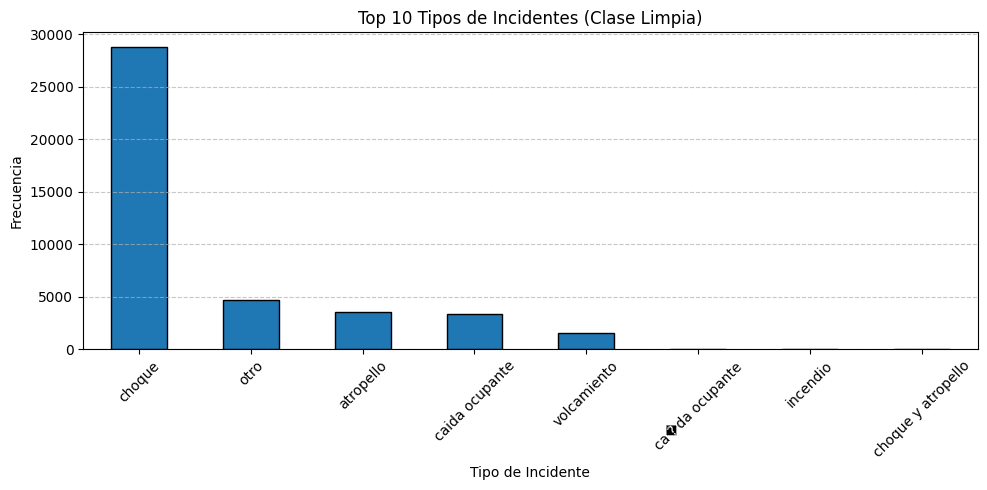

In [0]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. Traer datos de Spark a Pandas
# 'incidentes_limpios' es la tabla creada en el paso SQL anterior
df_limpio = spark.table("incidentes_limpios")

# Seleccionamos las columnas relevantes. 
# Si el dataset es muy grande, usa .limit(10000) o .sample(fraction=0.1)
pdf = df_limpio.select("clase_limpia", "fecha", "barrio_limpio").toPandas()

# 2. Preprocesamiento en Pandas (Feature Engineering)
# Convertimos fecha a datetime para extraer día y mes
pdf["fecha"] = pd.to_datetime(pdf["fecha"])
pdf["nombre_dia"] = pdf["fecha"].dt.day_name() # Ej: Monday, Tuesday
pdf["mes"] = pdf["fecha"].dt.month_name()      # Ej: January, February

# Mapeo de nombres de días de inglés a español
dias_es = {
    "Monday": "Lunes",
    "Tuesday": "Martes",
    "Wednesday": "Miércoles",
    "Thursday": "Jueves",
    "Friday": "Viernes",
    "Saturday": "Sábado",
    "Sunday": "Domingo"
}
pdf["nombre_dia_es"] = pdf["nombre_dia"].map(dias_es)

# --- GRÁFICO 1: Conteo por Clase ---
conteo = pdf["clase_limpia"].value_counts().head(10) # Limitamos al Top 10

plt.figure(figsize=(10, 5))
conteo.plot(kind="bar", color='#1f77b4', edgecolor='black') 

plt.title("Top 10 Tipos de Incidentes (Clase Limpia)")
plt.xlabel("Tipo de Incidente")
plt.ylabel("Frecuencia")
plt.xticks(rotation=45) # Rotar texto para que se lea bien
plt.grid(axis='y', linestyle='--', alpha=0.7) # Rejilla de fondo
plt.tight_layout()
plt.show()

In [0]:
import pandas as pd

# Definimos la ruta exacta
ruta_archivo = "/Volumes/workspace/big_data/actividad2/dataset.csv"

# Leemos el CSV con la codificación correcta
pdf = pd.read_csv(ruta_archivo, encoding="latin1")

# Convertimos la columna 'fecha' a datetime
pdf["fecha"] = pd.to_datetime(pdf["fecha"])

# Creamos la columna 'nombre_dia' extrayendo el nombre del día
pdf["nombre_dia"] = pdf["fecha"].dt.day_name()

/home/spark-89bccbc9-f9af-4370-8ae7-28/.ipykernel/4259/command-8362193914561465-707297313:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


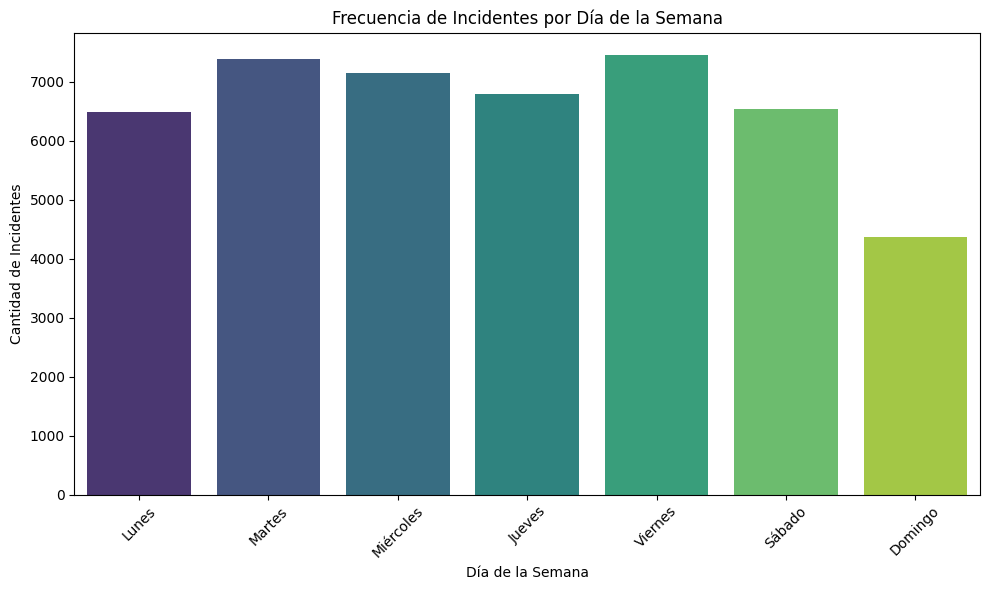

In [0]:
import seaborn as sns
import matplotlib.pyplot as plt

# Mapeo de nombres de días de inglés a español
if "nombre_dia" in pdf.columns:
    dias_es = {
        "Monday": "Lunes",
        "Tuesday": "Martes",
        "Wednesday": "Miércoles",
        "Thursday": "Jueves",
        "Friday": "Viernes",
        "Saturday": "Sábado",
        "Sunday": "Domingo"
    }
    pdf["nombre_dia_es"] = pdf["nombre_dia"].map(dias_es)
    columna_dia = "nombre_dia_es"
    orden_dias = ['Lunes', 'Martes', 'Miércoles', 'Jueves', 'Viernes', 'Sábado', 'Domingo']
else:
    columna_dia = "nombre_dia"
    orden_dias = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

plt.figure(figsize=(10, 6))

sns.countplot(
    data=pdf, 
    x=columna_dia,    # Eje X: Los días
    order=orden_dias,  # Ordenamos cronológicamente
    palette="viridis"  # Paleta de colores para diferenciar
)

plt.title("Frecuencia de Incidentes por Día de la Semana") # Título corregido
plt.xlabel("Día de la Semana")
plt.ylabel("Cantidad de Incidentes") # El eje Y ahora es 'Conteo'
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()